# Attention Mechanisms
An **attention mechanism** learns how to score the *importance* of each item in the input.
It takes into account *context* to infer the importance of the items.
## Attention mechanisms learn relative input importance

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import torch
import torchvision
from torchvision import transforms, datasets
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm.autonotebook import tqdm
from sklearn.metrics import accuracy_score

# Import dl_utils
import sys, os
sys.path.insert(0, os.path.abspath("../DL_utils_EZA"))
%load_ext autoreload
%autoreload 2
from dl_utils import *
print("dl_utils loaded ✅")

# ── Device setup ──────────────────────────────────────────────────────────────
# cudnn.benchmark = True  → optimal for fixed-size inputs (convolutional GANs)
# cudnn.benchmark = False → safer for FC-only GANs with variable shapes
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

/tmp/ipykernel_15249/1858903610.py:10: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


dl_utils loaded ✅
Device : cuda
GPU    : NVIDIA GeForce RTX 2080 Ti
VRAM   : 11.35 GB


In [2]:
# Downloading the MNIST data set
mnist_data_train = torchvision.datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
mnist_data_test = torchvision.datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())


In [3]:
class LargestDigit(Dataset):
    """ 
    Creates a modified version of a dataset where some number of samples are taken, 
    and the true labes is the largest label sampled. When used with MNIST, the labels
    correspond to their values (g.g., digit : '6' has label 6)
    """

    def __init__(self, dataset, toSample=3):
        """ 
        dataset:  the data set to sample from (e.g., MNIST)
        toSample: the number of samples to take from the dataset for each new sample
        """
        self.dataset = dataset
        self.toSample = toSample

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        # Randomly select `toSample` samples from the dataset
        selected = np.random.randint(0, len(self.dataset), size=self.toSample)
        # Stack the selected samples and find the maximum label
        x_new = torch.stack([self.dataset[i][0] for i in selected])
        y_new = max([self.dataset[i][1] for i in selected])
        
        return x_new, y_new

In [4]:
# Training the baseline model
B = 128
epochs = 30
largest_train = LargestDigit(mnist_data_train, toSample=3)
largest_test = LargestDigit(mnist_data_test, toSample=3)

# Data Loader
mnist_train_loader = DataLoader(largest_train, 
                                batch_size=B, 
                                shuffle=True, 
                                num_workers=4, 
                                pin_memory=True, 
                                persistent_workers=True,
                                drop_last=True
                                )
mnist_test_loader = DataLoader(largest_test, 
                               batch_size=B,
                               shuffle=False,
                               num_workers=4,
                               persistent_workers=True
                               )

True label is =  7


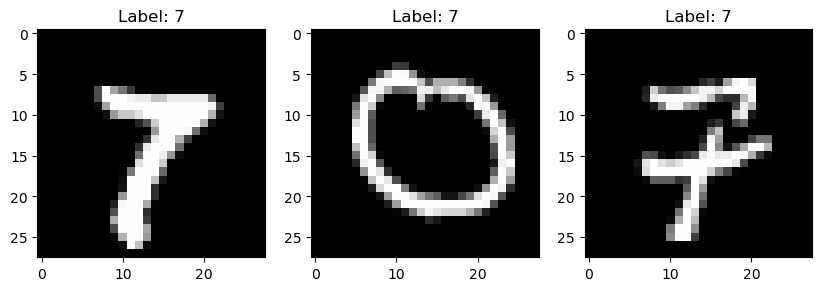

In [5]:
# Plot the transformed dataset to show that the set can 
# teach the model to ignore the smaller digists
x, y = largest_train[0]
f, axarr = plt.subplots(1, 3, figsize=(10, 10))
for i in range(3):
    axarr[i].imshow(x[i][0], cmap='gray')
    axarr[i].set_title(f"Label: {y}")
print('True label is = ', y)

In [6]:
# Train the baseline model with toy MNIST problem
neurons = 256#sns.lineplot(x="epoch", y="test loss", data=simple_results, label="Regular")
classes = 10
simpleNet = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784*3, neurons),
    nn.LeakyReLU(),
    nn.BatchNorm1d(neurons),
    nn.Linear(neurons, neurons),
    nn.LeakyReLU(),
    nn.BatchNorm1d(neurons),
    nn.Linear(neurons, neurons),
    nn.LeakyReLU(),
    nn.BatchNorm1d(neurons),
    nn.Linear(neurons, classes)
)

In [8]:
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run
torch.backends.cudnn.benchmark = False  # True is better for CNNs with fixed input sizes

# train_network_EZA instructions:
"""
                      (model, 
                      loss_func, 
                      train_loader, 
                      test_loader=None,
                      score_funcs=None, 
                      epochs=300, 
                      device='cpu',                      
                      checkpoint_file=None, 
                      resume_from_checkpoint=None,
                      checkpoint_every_x=None, 
                      use_amp=True,
                      optimizer=None,
                      lr_schedule=None,
                      val_loader=None)seg_results

    Train neural networks with EZA improvements.

    Keyword arguments:
    model                  -- PyTorch model to train
    loss_func              -- loss function (outputs, labels) -> score
    train_loader           -- DataLoader returning (input, label) tuples
    test_loader            -- Optional DataLoader for evaluation after every epoch
    score_funcs            -from sklearn.metrics import accuracy_score- dict of scoring functions e.g. {'Accuracy': accuracy_score}
    epochs                 -- number of training epochs
    device                 -- 'cuda' or 'cpu'
    checkpoint_file        -- path to save final checkpoint
    resume_from_checkpoint -- path to load checkpoint from to resume training
    checkpoint_every_x     -- save intermediate checkpoint every X epochs
    use_amp                -- enable Automatic Mixed Precision (RTX GPUs)
    optimizer              -- if none selected it uses AdamW optimizer
    lr_schedule            -- uses the ReduceLROPlateu function.
    val_loader             -- Optional PyTorch DataLoader to evaluate on after every epoch

    Returns: pd.DataFrame with training history

    ---------------seg_results---------------------------------------------------------------------------
    
    Improves over the train_simple_network:
    - Uses new optimizers and schedulers

"""

simple_results = train_network_EZA(simpleNet,
                                   nn.CrossEntropyLoss(),
                                   mnist_train_loader,
                                   val_loader=mnist_test_loader,
                                   epochs=epochs,
                                   use_amp=True,
                                   score_funcs= {'Accuracy': accuracy_score},
                                   device=device)

Epoch: 100%|██████████| 30/30 [08:46<00:00, 17.53s/it]


<Axes: xlabel='epoch', ylabel='val loss'>

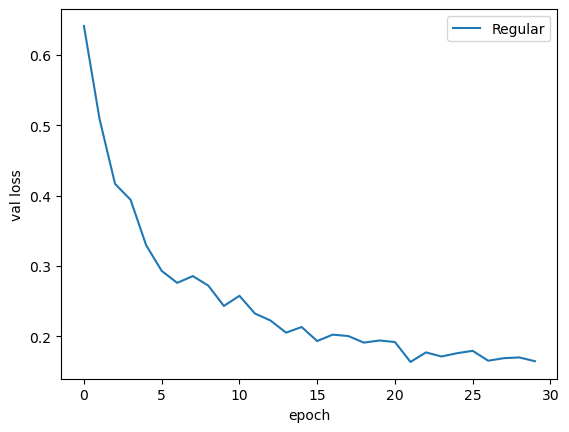

In [9]:
sns.lineplot(x="epoch", y="val loss", data=simple_results, label="Regular")

<Axes: xlabel='epoch', ylabel='val Accuracy'>

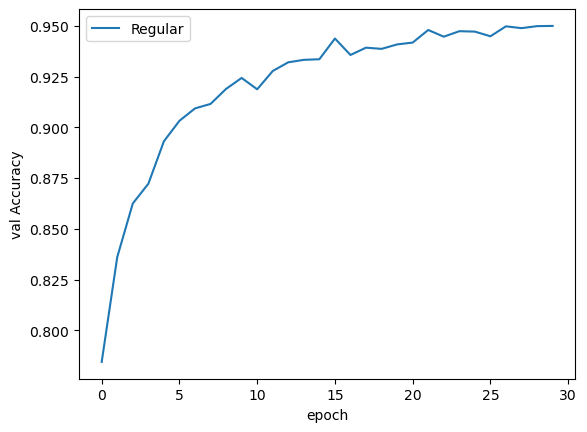

In [12]:
sns.lineplot(x="epoch", y="val Accuracy", data=simple_results, label="Regular")

### Implementing a simple **Attention Mechanism**